# Part 1: Environment Setup & Data Preparation

This module sets up the environment and creates the data loaders. Images are resized to 128x128, normalized to [-1, 1], and loaded in pairs.

In [1]:
import os
import glob
import gc
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch.amp as amp

# Configuration
class Config:
    PHOTO_PATH = '/kaggle/input/datasets/ankitsheoran23/sketch-to-image/256x256/photo/tx_000000000000'
    SKETCH_PATH = '/kaggle/input/datasets/ankitsheoran23/sketch-to-image/256x256/sketch/tx_000000000000'
    IMG_SIZE = 128
    BATCH_SIZE = 1  # Reduced to fit T4x2
    LR = 0.0001
    BETAS = (0.5, 0.999)
    EPOCHS = 30
    NUM_CLASSES = 20
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

config = Config()

class UnpairedDataset(Dataset):
    def __init__(self, photo_root, sketch_root, num_classes=20, transform=None):
        self.transform = transform
        self.pairs = []
        
        photo_classes = sorted([d for d in os.listdir(photo_root) if os.path.isdir(os.path.join(photo_root, d))])
        sketch_classes = sorted([d for d in os.listdir(sketch_root) if os.path.isdir(os.path.join(sketch_root, d))])
        common_classes = [c for c in photo_classes if c in sketch_classes][:num_classes]

        for cls in common_classes:
            p_folder = os.path.join(photo_root, cls)
            s_folder = os.path.join(sketch_root, cls)
            p_images = sorted(glob.glob(os.path.join(p_folder, "*.*")))
            s_images = sorted(glob.glob(os.path.join(s_folder, "*.*")))
            
            limit = min(len(p_images), len(s_images))
            for i in range(limit):
                self.pairs.append((s_images[i], p_images[i]))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        s_path, p_path = self.pairs[index]
        sketch_img = Image.open(s_path).convert("RGB")
        photo_img = Image.open(p_path).convert("RGB")

        if self.transform:
            sketch_img = self.transform(sketch_img)
            photo_img = self.transform(photo_img)
        return sketch_img, photo_img

transform_pipeline = transforms.Compose([
    transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

dataset = UnpairedDataset(config.PHOTO_PATH, config.SKETCH_PATH, config.NUM_CLASSES, transform_pipeline)
loader = DataLoader(dataset, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

# --- NEW PRINT STATEMENTS FOR VERIFICATION ---
print("--- Configuration Summary ---")
print(f"Device in use: {config.DEVICE}")
print(f"Batch Size: {config.BATCH_SIZE}")
print(f"Learning Rate: {config.LR}")
print(f"Target Image Size: {config.IMG_SIZE}x{config.IMG_SIZE}")
print(f"Number of target classes: {config.NUM_CLASSES}")

print("\n--- Dataset Summary ---")
print(f"Total unpaired image pairs loaded: {len(dataset)}")

# Fetch one single batch to verify shapes and normalization
sample_sketches, sample_photos = next(iter(loader))
print(f"\n--- DataLoader Verification ---")
print(f"Sample Sketch Batch Shape: {sample_sketches.shape}") # Should be [1, 3, 128, 128]
print(f"Sample Photo Batch Shape: {sample_photos.shape}")   # Should be [1, 3, 128, 128]
print(f"Data Range: min={sample_sketches.min().item():.2f}, max={sample_sketches.max().item():.2f}") # Should be approx -1.0 to 1.0

--- Configuration Summary ---
Device in use: cuda
Batch Size: 1
Learning Rate: 0.0001
Target Image Size: 128x128
Number of target classes: 20

--- Dataset Summary ---
Total unpaired image pairs loaded: 2000

--- DataLoader Verification ---
Sample Sketch Batch Shape: torch.Size([1, 3, 128, 128])
Sample Photo Batch Shape: torch.Size([1, 3, 128, 128])
Data Range: min=-1.00, max=1.00


# Part 2: Model Architecture

This module defines the ResNet-based Generator (with exactly 6 blocks as requested) and the PatchGAN Discriminator.

In [2]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, padding_mode="reflect"),
            nn.InstanceNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1, padding_mode="reflect"),
            nn.InstanceNorm2d(channels)
        )
    def forward(self, x):
        return x + self.block(x)

class Generator(nn.Module):
    def __init__(self, img_channels=3, num_features=64, num_residuals=6):
        super().__init__()
        self.initial = nn.Sequential(
            nn.Conv2d(img_channels, num_features, 7, stride=1, padding=3, padding_mode="reflect"),
            nn.InstanceNorm2d(num_features),
            nn.ReLU(inplace=True)
        )
        self.down_blocks = nn.Sequential(
            nn.Conv2d(num_features, num_features*2, 3, stride=2, padding=1),
            nn.InstanceNorm2d(num_features*2),
            nn.ReLU(inplace=True),
            nn.Conv2d(num_features*2, num_features*4, 3, stride=2, padding=1),
            nn.InstanceNorm2d(num_features*4),
            nn.ReLU(inplace=True)
        )
        self.res_blocks = nn.Sequential(*[ResidualBlock(num_features*4) for _ in range(num_residuals)])
        self.up_blocks = nn.Sequential(
            nn.ConvTranspose2d(num_features*4, num_features*2, 3, stride=2, padding=1, output_padding=1),
            nn.InstanceNorm2d(num_features*2),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(num_features*2, num_features, 3, stride=2, padding=1, output_padding=1),
            nn.InstanceNorm2d(num_features),
            nn.ReLU(inplace=True)
        )
        self.last = nn.Conv2d(num_features, img_channels, 7, stride=1, padding=3, padding_mode="reflect")

    def forward(self, x):
        return torch.tanh(self.last(self.up_blocks(self.res_blocks(self.down_blocks(self.initial(x))))))

class Discriminator(nn.Module):
    def __init__(self, in_channels=3, features=[64, 128, 256, 512]):
        super().__init__()
        self.initial = nn.Sequential(
            nn.Conv2d(in_channels, features[0], 4, stride=2, padding=1, padding_mode="reflect"),
            nn.LeakyReLU(0.2, inplace=True)
        )
        layers = []
        in_f = features[0]
        for feature in features[1:]:
            stride = 1 if feature == features[-1] else 2
            layers.append(nn.Sequential(
                nn.Conv2d(in_f, feature, 4, stride=stride, padding=1, padding_mode="reflect"),
                nn.InstanceNorm2d(feature),
                nn.LeakyReLU(0.2, inplace=True)
            ))
            in_f = feature
        layers.append(nn.Conv2d(in_f, 1, 4, stride=1, padding=1, padding_mode="reflect"))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return torch.sigmoid(self.model(self.initial(x)))

# Initialization (Dual GPU)
gen_S2P = nn.DataParallel(Generator().to(config.DEVICE))
gen_P2S = nn.DataParallel(Generator().to(config.DEVICE))
disc_P = nn.DataParallel(Discriminator().to(config.DEVICE))
disc_S = nn.DataParallel(Discriminator().to(config.DEVICE))

# Part 3: Forward Pass & Training Setup

This section includes the loss functions, optimizers, and the robust training loop using mixed precision.

In [4]:
L1_LOSS = nn.L1Loss()
MSE_LOSS = nn.MSELoss()

# Remember to update the learning rate to 0.0001 since the batch size is now 2
opt_gen = optim.Adam(list(gen_S2P.parameters()) + list(gen_P2S.parameters()), lr=0.0001, betas=config.BETAS)
opt_disc = optim.Adam(list(disc_P.parameters()) + list(disc_S.parameters()), lr=0.0001, betas=config.BETAS)

scaler = amp.GradScaler('cuda')

# Storage for plotting
history = {'G_loss': [], 'D_loss': [], 'Cycle_loss': []}

for epoch in range(config.EPOCHS):
    loop = tqdm(loader, leave=True)
    epoch_G_loss, epoch_D_loss, epoch_cycle_loss = 0, 0, 0
    
    for idx, (sketch, photo) in enumerate(loop):
        sketch, photo = sketch.to(config.DEVICE), photo.to(config.DEVICE)

        # Train Discriminators
        with amp.autocast('cuda'):
            fake_photo = gen_S2P(sketch)
            fake_sketch = gen_P2S(photo)
            
            # FIXED: Replaced 'mse' with 'MSE_LOSS'
            D_P_real = MSE_LOSS(disc_P(photo), torch.ones_like(disc_P(photo)))
            D_P_fake = MSE_LOSS(disc_P(fake_photo.detach()), torch.zeros_like(disc_P(fake_photo)))
            loss_D_P = D_P_real + D_P_fake

            D_S_real = MSE_LOSS(disc_S(sketch), torch.ones_like(disc_S(sketch)))
            D_S_fake = MSE_LOSS(disc_S(fake_sketch.detach()), torch.zeros_like(disc_S(fake_sketch)))
            loss_D_S = D_S_real + D_S_fake
            
            loss_D = (loss_D_P + loss_D_S) / 2

        opt_disc.zero_grad(set_to_none=True)
        scaler.scale(loss_D).backward()
        scaler.step(opt_disc)
        
        # Train Generators
        with amp.autocast('cuda'):
            # FIXED: Replaced 'mse' with 'MSE_LOSS'
            loss_G_P = MSE_LOSS(disc_P(fake_photo), torch.ones_like(disc_P(fake_photo)))
            loss_G_S = MSE_LOSS(disc_S(fake_sketch), torch.ones_like(disc_S(fake_sketch)))
            
            cycle_photo = gen_S2P(fake_sketch)
            cycle_sketch = gen_P2S(fake_photo)
            cycle_loss = L1_LOSS(photo, cycle_photo) + L1_LOSS(sketch, cycle_sketch)
            
            id_photo = gen_S2P(photo)
            id_sketch = gen_P2S(sketch)
            id_loss = L1_LOSS(photo, id_photo) + L1_LOSS(sketch, id_sketch)
            
            loss_G = loss_G_P + loss_G_S + (cycle_loss * 10.0) + (id_loss * 5.0)

        opt_gen.zero_grad(set_to_none=True)
        scaler.scale(loss_G).backward()
        scaler.step(opt_gen)
        scaler.update()

        epoch_G_loss += loss_G.item()
        epoch_D_loss += loss_D.item()
        epoch_cycle_loss += cycle_loss.item()

    history['G_loss'].append(epoch_G_loss / len(loader))
    history['D_loss'].append(epoch_D_loss / len(loader))
    history['Cycle_loss'].append(epoch_cycle_loss / len(loader))
    
    # Save checkpoint and clear memory
    if (epoch + 1) % 10 == 0:
        torch.save(gen_S2P.state_dict(), f'gen_s2p_epoch_{epoch+1}.pth')
        torch.save(gen_P2S.state_dict(), f'gen_p2s_epoch_{epoch+1}.pth')
    
    gc.collect()
    torch.cuda.empty_cache()

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

...

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

# Part 4: Visualization Module & Training Logs

This function displays the required input, output, and ground truth images for visual comparison.

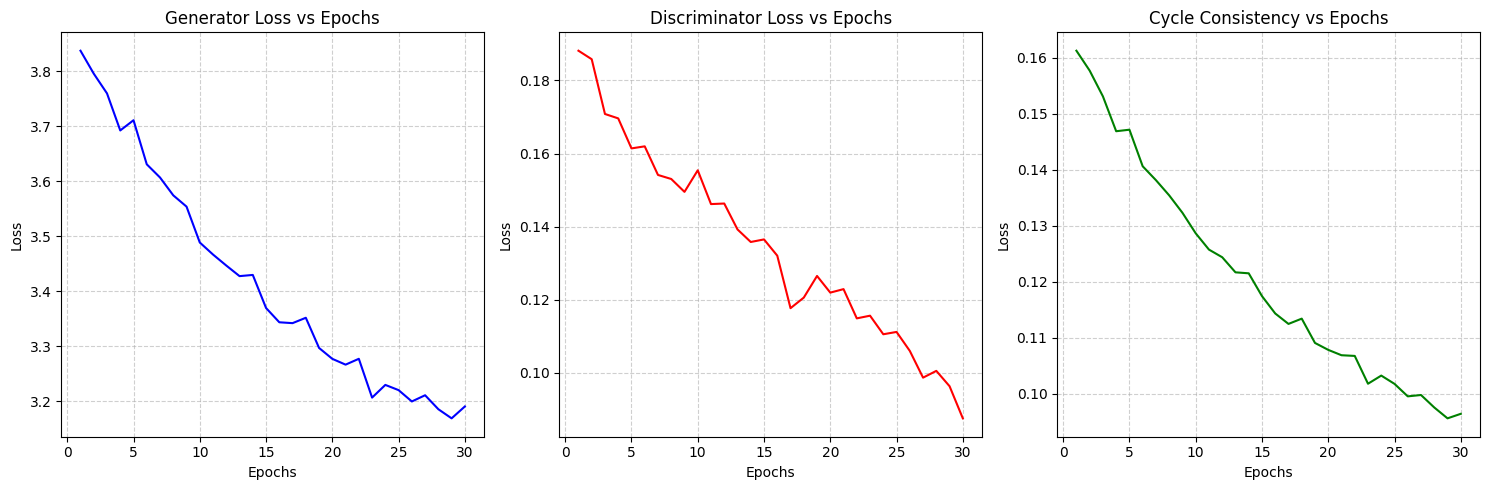

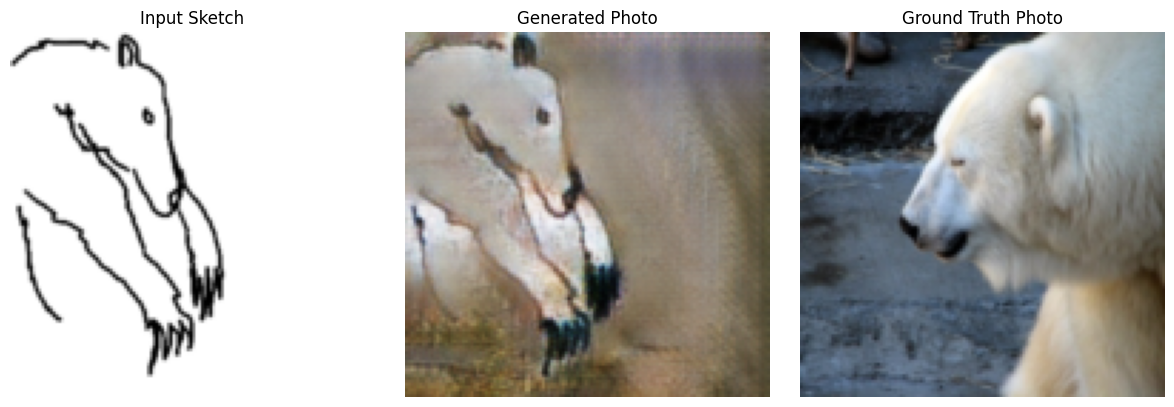

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def visualize_results(loader, gen_model, device, num_examples=5):
    gen_model.eval()
    sketches, photos = next(iter(loader))
    
    # Dynamically adjust to batch size to prevent IndexError
    actual_examples = min(num_examples, sketches.size(0))
    
    sketches = sketches[:actual_examples].to(device)
    photos = photos[:actual_examples]
    
    with torch.no_grad():
        generated_photos = gen_model(sketches).cpu()
    
    sketches = sketches.cpu()
    
    # squeeze=False ensures axes is always a 2D array even if batch is 1
    fig, axes = plt.subplots(actual_examples, 3, figsize=(12, actual_examples * 4), squeeze=False)
    
    for i in range(actual_examples):
        # Denormalize images from [-1, 1] to [0, 1]
        s_img = (sketches[i].permute(1, 2, 0).numpy() * 0.5) + 0.5
        g_img = (generated_photos[i].permute(1, 2, 0).numpy() * 0.5) + 0.5
        p_img = (photos[i].permute(1, 2, 0).numpy() * 0.5) + 0.5
        
        # Clip to ensure valid range for matplotlib
        s_img = np.clip(s_img, 0, 1)
        g_img = np.clip(g_img, 0, 1)
        p_img = np.clip(p_img, 0, 1)
        
        axes[i, 0].imshow(s_img)
        axes[i, 0].set_title("Input Sketch")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(g_img)
        axes[i, 1].set_title("Generated Photo")
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(p_img)
        axes[i, 2].set_title("Ground Truth Photo")
        axes[i, 2].axis('off')
        
    plt.tight_layout()
    plt.show()

def plot_logs(history):
    if not history or not history.get('G_loss'):
        print("No training history found to plot.")
        return
        
    epochs = range(1, len(history['G_loss']) + 1)
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['G_loss'], label='Generator Loss', color='blue')
    plt.title('Generator Loss vs Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['D_loss'], label='Discriminator Loss', color='red')
    plt.title('Discriminator Loss vs Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.subplot(1, 3, 3)
    plt.plot(epochs, history['Cycle_loss'], label='Cycle Loss', color='green')
    plt.title('Cycle Consistency vs Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# Execution calls
plot_logs(history)
visualize_results(loader, gen_S2P, config.DEVICE)

# Part 5: Quantitative Evaluation (SSIM & PSNR)

Calculates structural consistency metrics on the testing batch.

In [42]:
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from tqdm.auto import tqdm

def evaluate_model_full(loader, gen_model, device):
    gen_model.eval()
    
    total_ssim = 0
    total_psnr = 0
    total_samples = 0
    
    print("Running full dataset evaluation...")
    
    # Loop through EVERY batch in the DataLoader
    with torch.no_grad():
        for sketches, real_photos in tqdm(loader, desc="Evaluating"):
            sketches = sketches.to(device)
            fake_photos = gen_model(sketches).cpu()
            
            real_photos = real_photos.numpy()
            fake_photos = fake_photos.numpy()
            
            batch_size = len(real_photos)
            
            for i in range(batch_size):
                # Denormalize and format for skimage (Height, Width, Channels)
                real_img = (real_photos[i].transpose(1, 2, 0) * 0.5) + 0.5
                fake_img = (fake_photos[i].transpose(1, 2, 0) * 0.5) + 0.5
                
                # Clip limits to 0.0 and 1.0 strictly for metric calculation
                real_img = np.clip(real_img, 0, 1)
                fake_img = np.clip(fake_img, 0, 1)
                
                total_ssim += ssim(real_img, fake_img, data_range=1.0, channel_axis=2)
                total_psnr += psnr(real_img, fake_img, data_range=1.0)
                
            total_samples += batch_size
            
    print("\n--- Final Quantitative Evaluation ---")
    print(f"Total Images Evaluated: {total_samples}")
    print(f"Overall Average SSIM: {total_ssim / total_samples:.4f}")
    print(f"Overall Average PSNR: {total_psnr / total_samples:.4f} dB")

# Run the full evaluation
evaluate_model_full(loader, gen_S2P, config.DEVICE)

Running full dataset evaluation...


Evaluating:   0%|          | 0/2000 [00:00<?, ?it/s]


--- Final Quantitative Evaluation ---
Total Images Evaluated: 2000
Overall Average SSIM: 0.1149
Overall Average PSNR: 9.5160 dB


App Deployment (Gradio Interface)

In [45]:
# You may need to run !pip install gradio first if it is not installed
import gradio as gr
import torch
import numpy as np

def translate_image(input_img):
    if input_img is None:
        return None
        
    # Preprocess the input PIL image into a PyTorch tensor
    img_tensor = transform_pipeline(input_img).unsqueeze(0).to(config.DEVICE)
    
    # Run through the model
    with torch.no_grad():
        gen_S2P.eval()
        output_tensor = gen_S2P(img_tensor).cpu().squeeze(0)
        
    # Post-process back to a standard image format
    output_img = (output_tensor.permute(1, 2, 0).numpy() * 0.5) + 0.5
    output_img = np.clip(output_img, 0, 1)
    
    return output_img

# Define the Gradio Interface
app = gr.Interface(
    fn=translate_image,
    inputs=gr.Image(type="pil", label="Upload Sketch"),
    outputs=gr.Image(label="Generated Photo Output"),
    title="CycleGAN: Sketch to Photo Translator",
    description="Upload a 128x128 sketch to generate a realistic photo using a custom ResNet-6 Generator.",
    flagging_mode="never"
)

# Launch the app. share=True creates a public URL you can access outside Kaggle
app.launch(share=True)

* Running on local URL:  http://127.0.0.1:7864
* Running on public URL: https://eed7fca0d507a6e631.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
